# 01 — Tree Models Optimisé : Random Forest, XGBoost, LightGBM

**Pipeline complet fusionné (01 + 04) — inspiré des solutions 1ère place Kaggle :**

### Preprocessing & Feature Engineering
- UID précis (`card1 + addr1 + D1n`) — identifie chaque client de manière quasi-unique
- Group aggregations par UID : mean, std de TransactionAmt, D4, D9, D10, D15, C1, C13, C14
- Features dérivées : `_diff`, `_ratio`, `_zscore`, `uid_nb_tx`, `uid_nb_cards`, `uid_time_delta`
- Frequency encoding sur colonnes simples + combos (card1_addr1, card1_addr1_P_email)
- `outsider15` : `|D1 - D15| > 3`

### Évaluation
- Split **train / val / test** temporel (60/20/20)
- Métriques **AUC-ROC + AUC-PR** sur val ET test
- Réentraînement sur 100% pour soumission Kaggle

**⚠️ Prérequis :** exécuter d'abord `00_common_preprocessing.ipynb`

## 1. Imports

In [1]:
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb, xgboost as xgb
import warnings; warnings.filterwarnings('ignore')

train = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/train_base.pkl')
test_kaggle  = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/test_kaggle.pkl')
print(f'Train: {train.shape} | Test Kaggle: {test_kaggle.shape}')

Train: (590540, 427) | Test Kaggle: (506691, 426)


## 2. ⭐ UID client précis

`D1` = jours depuis la 1ère transaction de cette carte.
→ `day - D1` = **jour de création de la carte** (invariant pour un même client).
Combiné avec `card1 + addr1`, ça identifie un client de manière quasi-unique.

In [2]:
for df in [train, test_kaggle]:
    df['day'] = df['TransactionDT'] // (24*60*60)
    df['D1n'] = df['day'] - df['D1']
    # UID unique et précis
    df['uid'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].astype(str) + '_' +
                 df['D1n'].astype(str))
    # Combos pour frequency encoding
    df['card1_addr1']         = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    df['card1_addr1_P_email'] = df['card1_addr1'] + '_' + df['P_emaildomain'].astype(str)
    # outsider15
    df['outsider15'] = (np.abs(df['D1'].fillna(0) - df['D15'].fillna(0)) > 3).astype(np.int8)

print(f"UIDs uniques train: {train['uid'].nunique():,}")
print(f"UIDs uniques test:  {test_kaggle['uid'].nunique():,}")
print(f"Transactions/UID (moy): {len(train) / train['uid'].nunique():.1f}")

UIDs uniques train: 217,850
UIDs uniques test:  196,187
Transactions/UID (moy): 2.7


## 3. Frequency encoding (sur train + test_kaggle combiné)

In [3]:
FE_COLS = ['card1','card2','card3','card5','addr1','addr2',
           'P_emaildomain','R_emaildomain',
           'uid','card1_addr1','card1_addr1_P_email']
FE_COLS = [c for c in FE_COLS if c in train.columns]

full_fe = pd.concat([train, test_kaggle], ignore_index=True)
for c in FE_COLS:
    vc = full_fe[c].astype(str).value_counts(dropna=False, normalize=True).to_dict()
    train[f'{c}_FE']       = train[c].astype(str).map(vc).astype(np.float32)
    test_kaggle[f'{c}_FE'] = test_kaggle[c].astype(str).map(vc).astype(np.float32)
del full_fe; gc.collect()
print(f'Frequency encoding: {len(FE_COLS)} colonnes')

Frequency encoding: 11 colonnes


## 4. ⭐ Group aggregations par UID (magic features)

Pour chaque (feature, UID) on calcule mean et std.
Puis on dérive : `_diff` (écart absolu), `_ratio`, `_zscore`.

In [4]:
AGG_COLS = ['TransactionAmt','D4','D9','D10','D15','C1','C13','C14']
AGG_COLS = [c for c in AGG_COLS if c in train.columns]

full_agg = pd.concat([train, test_kaggle], ignore_index=True)
for col in AGG_COLS:
    agg = full_agg.groupby('uid')[col].agg(['mean','std'])
    mean_map = agg['mean'].to_dict()
    std_map  = agg['std'].to_dict()
    for df in [train, test_kaggle]:
        df[f'{col}_uid_mean'] = df['uid'].map(mean_map).astype(np.float32)
        df[f'{col}_uid_std']  = df['uid'].map(std_map).astype(np.float32)
        # Diff : transaction courante vs moyenne du client
        df[f'{col}_uid_diff'] = (df[col] - df[f'{col}_uid_mean']).astype(np.float32)

del full_agg; gc.collect()
print(f'Aggregations: {len(AGG_COLS)} features × (mean, std, diff) = {len(AGG_COLS)*3} nouvelles colonnes')

Aggregations: 8 features × (mean, std, diff) = 24 nouvelles colonnes


## 5. ⭐ Features dérivées avancées (ratio, zscore, activité, time delta)

Ces features capturent le **comportement anormal** d'un client :
- `amt_ratio` : transaction / moyenne du client (ratio > 3 → suspect)
- `amt_zscore` : z-score par client (normalise par la variabilité)
- `uid_nb_tx` : nombre total de transactions du client
- `uid_nb_cards` : nombre de cartes distinctes (>1 → suspect)
- `uid_time_delta` : temps entre transactions consécutives du même client

In [5]:
# Ratio et Z-score
for df in [train, test_kaggle]:
    df['amt_ratio_uid']  = (df['TransactionAmt'] /
                            (df['TransactionAmt_uid_mean'] + 1)).astype(np.float32)
    df['amt_zscore_uid'] = ((df['TransactionAmt'] - df['TransactionAmt_uid_mean']) /
                            (df['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)

# Nb transactions par UID
for df in [train, test_kaggle]:
    df['uid_nb_tx']    = df.groupby('uid')['TransactionID'].transform('count').astype(np.int32)
    df['uid_nb_cards'] = df.groupby('uid')['card1'].transform('nunique').astype(np.int16)

# Time delta entre transactions consécutives du même client
for df in [train, test_kaggle]:
    df.sort_values(['uid','TransactionDT'], inplace=True)
    df['uid_time_delta'] = df.groupby('uid')['TransactionDT'].diff().astype(np.float32)
    df['uid_time_delta'].fillna(-1, inplace=True)
    df.sort_index(inplace=True)

print('Features dérivées ajoutées: amt_ratio, amt_zscore, uid_nb_tx, uid_nb_cards, uid_time_delta')

Features dérivées ajoutées: amt_ratio, amt_zscore, uid_nb_tx, uid_nb_cards, uid_time_delta


## 6. Drop UID brut + Label encoding catégorielles

In [6]:
# Drop les UIDs (trop bruyants, on garde seulement les features dérivées)
DROP = ['uid','card1_addr1','card1_addr1_P_email','day','D1n']
for df in [train, test_kaggle]:
    df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

cat_cols = [c for c in train.columns if train[c].dtype == 'object']
print(f'{len(cat_cols)} catégorielles à label encoder')
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test_kaggle[col]]).astype(str).fillna('missing')
    le.fit(combined)
    train[col]       = le.transform(train[col].astype(str).fillna('missing')).astype(np.int32)
    test_kaggle[col] = le.transform(test_kaggle[col].astype(str).fillna('missing')).astype(np.int32)

39 catégorielles à label encoder


## 7. Imputation -999 + split temporel 60/20/20

In [7]:
train.fillna(-999, inplace=True)
test_kaggle.fillna(-999, inplace=True)

FEATURES = [c for c in train.columns if c not in ('isFraud','TransactionID','TransactionDT','DT_M')]
print(f'Total features: {len(FEATURES)}')

# Split temporel
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
n = len(train_sorted)
i1, i2 = int(n*0.6), int(n*0.8)

X_tr,  y_tr  = train_sorted.loc[:i1-1,   FEATURES], train_sorted.loc[:i1-1,   'isFraud']
X_val, y_val = train_sorted.loc[i1:i2-1, FEATURES], train_sorted.loc[i1:i2-1, 'isFraud']
X_te,  y_te  = train_sorted.loc[i2:,     FEATURES], train_sorted.loc[i2:,     'isFraud']
print(f'Train: {X_tr.shape} ({y_tr.mean():.4f}) | '
      f'Val: {X_val.shape} ({y_val.mean():.4f}) | '
      f'Test: {X_te.shape} ({y_te.mean():.4f})')

Total features: 464
Train: (354324, 464) (0.0338) | Val: (118108, 464) (0.0390) | Test: (118108, 464) (0.0344)


## 8. Fonction d'évaluation (AUC-ROC + AUC-PR)

In [8]:
results = []
def evaluate(y_true, y_pred, name, split_name, ax_roc=None, ax_pr=None, color=None):
    auc_roc = roc_auc_score(y_true, y_pred)
    auc_pr  = average_precision_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    pr, rc, _   = precision_recall_curve(y_true, y_pred)
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc, pr,   color=color, label=f'{name} (AP={auc_pr:.4f})')
    print(f'  {split_name:5s} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f}')
    results.append({'model': name, 'split': split_name, 'auc_roc': auc_roc, 'auc_pr': auc_pr})
    return auc_roc, auc_pr

## 9. Random Forest

In [9]:
%%time
rf = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1,
                            class_weight='balanced', random_state=42)
rf.fit(X_tr, y_tr)
pred_rf_val = rf.predict_proba(X_val)[:, 1]
pred_rf_te  = rf.predict_proba(X_te)[:, 1]
print('RandomForest:')
evaluate(y_val, pred_rf_val, 'RandomForest', 'val')
evaluate(y_te,  pred_rf_te,  'RandomForest', 'test')

RandomForest:
  val   | AUC-ROC: 0.9071 | AUC-PR: 0.5511
  test  | AUC-ROC: 0.8617 | AUC-PR: 0.4370
CPU times: user 13min 49s, sys: 1.59 s, total: 13min 51s
Wall time: 3min 32s


(np.float64(0.8616707514912741), np.float64(0.4370331838872783))

## 10. LightGBM (hyperparamètres optimisés)

Paramètres alignés sur la solution 1ère place :
`num_leaves=512`, `lr=0.03`, `feature_fraction=0.5`, `early_stopping=150`

In [10]:
%%time
def auc_pr_lgb(y_pred, dataset):
    return 'auc_pr', average_precision_score(dataset.get_label(), y_pred), True

lgb_params = {
    'objective': 'binary',
    'metric': 'None',
    'learning_rate': 0.03,
    'num_leaves': 512,
    'min_child_samples': 80,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'is_unbalance': True,
    'verbose': -1,
}
dtr = lgb.Dataset(X_tr, y_tr)
dvl = lgb.Dataset(X_val, y_val)
model_lgb = lgb.train(lgb_params, dtr, num_boost_round=3000,
                      valid_sets=[dvl], feval=auc_pr_lgb,
                      callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)])
pred_lgb_val = model_lgb.predict(X_val)
pred_lgb_te  = model_lgb.predict(X_te)
print('LightGBM:')
evaluate(y_val, pred_lgb_val, 'LightGBM', 'val')
evaluate(y_te,  pred_lgb_te,  'LightGBM', 'test')

Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc_pr: 0.670572
[400]	valid_0's auc_pr: 0.699348
[600]	valid_0's auc_pr: 0.707501
[800]	valid_0's auc_pr: 0.712861
[1000]	valid_0's auc_pr: 0.716269
[1200]	valid_0's auc_pr: 0.718565
[1400]	valid_0's auc_pr: 0.718854
[1600]	valid_0's auc_pr: 0.720432
[1800]	valid_0's auc_pr: 0.721297
[2000]	valid_0's auc_pr: 0.721742
[2200]	valid_0's auc_pr: 0.721997
[2400]	valid_0's auc_pr: 0.722044
Early stopping, best iteration is:
[2334]	valid_0's auc_pr: 0.722173
LightGBM:
  val   | AUC-ROC: 0.9458 | AUC-PR: 0.7222
  test  | AUC-ROC: 0.9121 | AUC-PR: 0.5817
CPU times: user 1h 14min 6s, sys: 15.5 s, total: 1h 14min 21s
Wall time: 19min 9s


(np.float64(0.9120594526542732), np.float64(0.5816813782060044))

## 11. XGBoost (GPU, hyperparamètres optimisés)

In [11]:
%%time
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'learning_rate': 0.03,
    'max_depth': 12,
    'subsample': 0.8,
    'colsample_bytree': 0.4,
    'tree_method': 'hist',
    'device': 'cuda',
    'scale_pos_weight': (y_tr==0).sum() / (y_tr==1).sum(),
}
dtr_x = xgb.DMatrix(X_tr,  label=y_tr)
dvl_x = xgb.DMatrix(X_val, label=y_val)
dte_x = xgb.DMatrix(X_te,  label=y_te)
model_xgb = xgb.train(xgb_params, dtr_x, num_boost_round=3000,
                       evals=[(dvl_x,'val')], early_stopping_rounds=150, verbose_eval=200)
pred_xgb_val = model_xgb.predict(dvl_x)
pred_xgb_te  = model_xgb.predict(dte_x)
print('XGBoost:')
evaluate(y_val, pred_xgb_val, 'XGBoost', 'val')
evaluate(y_te,  pred_xgb_te,  'XGBoost', 'test')

[0]	val-aucpr:0.41741
[200]	val-aucpr:0.62698
[400]	val-aucpr:0.64871
[600]	val-aucpr:0.66223
[800]	val-aucpr:0.67286
[1000]	val-aucpr:0.68109
[1200]	val-aucpr:0.68802
[1400]	val-aucpr:0.69208
[1600]	val-aucpr:0.69531
[1800]	val-aucpr:0.69782
[2000]	val-aucpr:0.70006
[2200]	val-aucpr:0.70168
[2400]	val-aucpr:0.70281
[2600]	val-aucpr:0.70376
[2800]	val-aucpr:0.70405
[2999]	val-aucpr:0.70470
XGBoost:
  val   | AUC-ROC: 0.9455 | AUC-PR: 0.7047
  test  | AUC-ROC: 0.9124 | AUC-PR: 0.5773
CPU times: user 1h 28min 5s, sys: 7.18 s, total: 1h 28min 12s
Wall time: 22min 20s


(np.float64(0.9123948829616667), np.float64(0.5773499303433764))

## 12. Comparaison + courbes (sur test held-out)

  test  | AUC-ROC: 0.8617 | AUC-PR: 0.4370
  test  | AUC-ROC: 0.9121 | AUC-PR: 0.5817
  test  | AUC-ROC: 0.9124 | AUC-PR: 0.5773


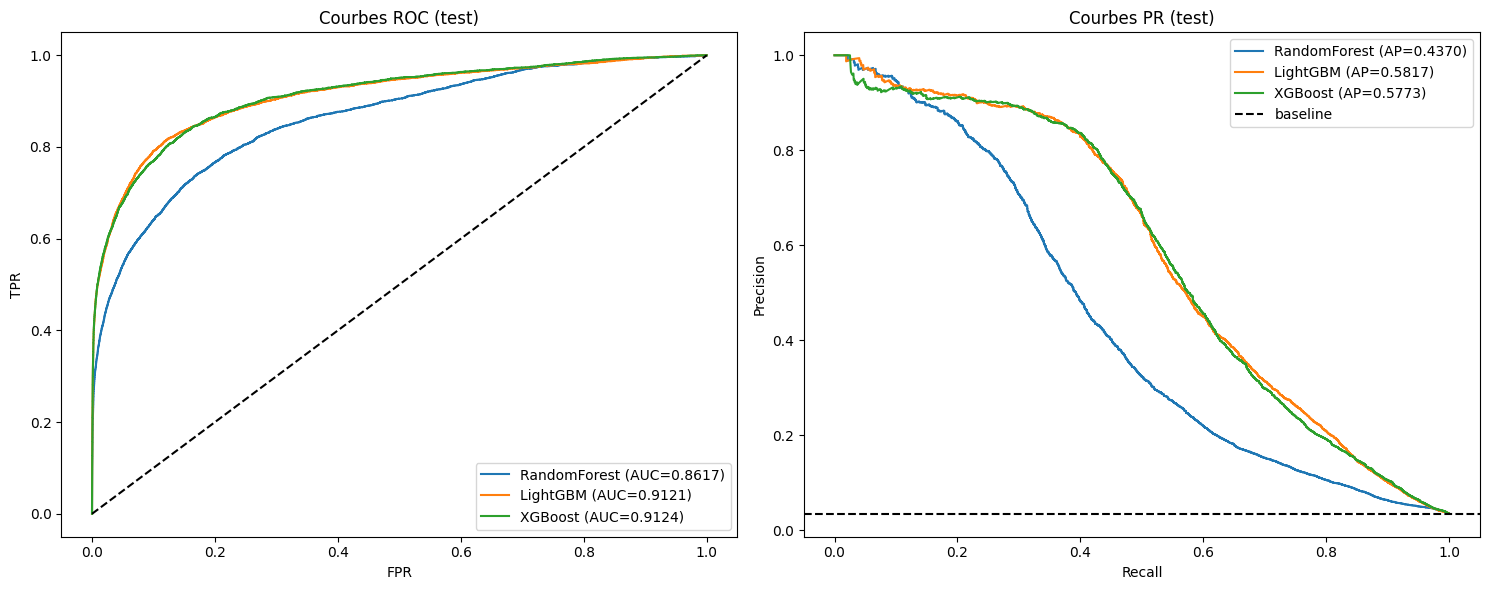

auc_pr             auc_roc          
split             test       val      test       val
model                                               
LightGBM      0.581681  0.722173  0.912059  0.945849
RandomForest  0.437033  0.551059  0.861671  0.907135
XGBoost       0.577350  0.704702  0.912395  0.945475

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = {'RandomForest':'C0', 'LightGBM':'C1', 'XGBoost':'C2'}
evaluate(y_te, pred_rf_te,  'RandomForest', 'test', ax1, ax2, colors['RandomForest'])
evaluate(y_te, pred_lgb_te, 'LightGBM',     'test', ax1, ax2, colors['LightGBM'])
evaluate(y_te, pred_xgb_te, 'XGBoost',      'test', ax1, ax2, colors['XGBoost'])
ax1.plot([0,1],[0,1],'k--'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Courbes ROC (test)'); ax1.legend()
ax2.axhline(y_te.mean(), color='k', ls='--', label='baseline')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Courbes PR (test)'); ax2.legend()
plt.tight_layout(); plt.show()
pd.DataFrame(results).pivot_table(index='model', columns='split', values=['auc_roc','auc_pr'])

## 13. Feature Importance (top 30)

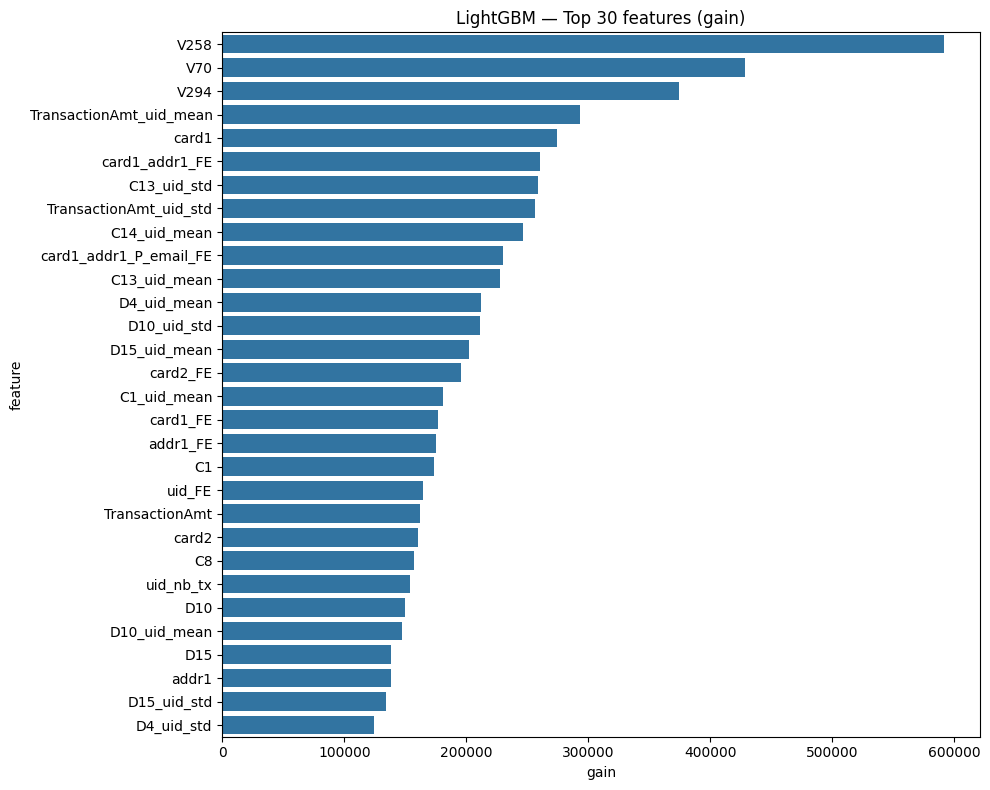


Features UID/magic dans le top 30: 19/30
                feature          gain
TransactionAmt_uid_mean 293408.930512
         card1_addr1_FE 260288.011598
            C13_uid_std 258999.238937
 TransactionAmt_uid_std 256606.067500
           C14_uid_mean 246406.796369
 card1_addr1_P_email_FE 230428.646845
           C13_uid_mean 227907.595012
            D4_uid_mean 212328.958752
            D10_uid_std 211490.921488
           D15_uid_mean 202602.050334
               card2_FE 195673.549298
            C1_uid_mean 181030.576195
               card1_FE 176609.120441
               addr1_FE 175307.529366
                 uid_FE 164654.721372
              uid_nb_tx 153868.286693
           D10_uid_mean 147625.961269
            D15_uid_std 133924.749687
             D4_uid_std 124238.918012


In [13]:
imp = pd.DataFrame({'feature': FEATURES,
                     'gain': model_lgb.feature_importance(importance_type='gain')})
imp = imp.sort_values('gain', ascending=False).head(30)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp, y='feature', x='gain')
plt.title('LightGBM — Top 30 features (gain)')
plt.tight_layout(); plt.show()

# Compter les features UID/magic dans le top 30
magic_mask = imp.feature.str.contains('uid|zscore|ratio|_FE|_diff|time_delta|outsider|nb_tx|nb_cards', regex=True)
print(f'\nFeatures UID/magic dans le top 30: {magic_mask.sum()}/30')
print(imp[magic_mask][['feature','gain']].to_string(index=False))

## 14. Réentraînement sur 100% des données labellisées

On fixe le nombre d'itérations à `best_iteration` trouvé par early stopping, puis on réentraîne sur train+val+test. Plus de données → meilleure généralisation → meilleur score Kaggle.

In [14]:
%time
X_full = pd.concat([X_tr, X_val, X_te], ignore_index=True)
y_full = pd.concat([y_tr, y_val, y_te], ignore_index=True)

# LightGBM full
dfull = lgb.Dataset(X_full, y_full)
model_lgb_full = lgb.train(lgb_params, dfull, num_boost_round=model_lgb.best_iteration)

# XGBoost full
dfull_x = xgb.DMatrix(X_full, label=y_full)
model_xgb_full = xgb.train(xgb_params, dfull_x, num_boost_round=model_xgb.best_iteration)

print(f'LGB retrained: {len(X_full):,} rows × {model_lgb.best_iteration} rounds')
print(f'XGB retrained: {len(X_full):,} rows × {model_xgb.best_iteration} rounds')

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 7.15 µs
LGB retrained: 590,540 rows × 2334 rounds
XGB retrained: 590,540 rows × 2996 rounds


## 15. Soumission Kaggle

In [15]:
X_kaggle = test_kaggle[FEATURES]

# Soumission LightGBM
sub_lgb = pd.DataFrame({'TransactionID': test_kaggle['TransactionID'],
                         'isFraud': model_lgb_full.predict(X_kaggle)})
sub_lgb.to_csv('/kaggle/working/submission_trees_lgb.csv', index=False)

# Soumission XGBoost
dk = xgb.DMatrix(X_kaggle)
sub_xgb = pd.DataFrame({'TransactionID': test_kaggle['TransactionID'],
                         'isFraud': model_xgb_full.predict(dk)})
sub_xgb.to_csv('/kaggle/working/submission_trees_xgb.csv', index=False)

print('=== LightGBM submission ===')
print(sub_lgb.isFraud.describe().round(4))
print('\n=== XGBoost submission ===')
print(sub_xgb.isFraud.describe().round(4))

=== LightGBM submission ===
count    506691.0000
mean          0.0195
std           0.1313
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           1.0000
Name: isFraud, dtype: float64

=== XGBoost submission ===
count    506691.0000
mean          0.0222
std           0.1329
min           0.0000
25%           0.0000
50%           0.0001
75%           0.0006
max           1.0000
Name: isFraud, dtype: float64
